# XGBFR 02 — Threshold Analysis

Evaluate the Precision / Recall / F1 trade-off across a dense validation-only threshold grid.

In [1]:
# Import libraries
from pathlib import Path
import sys

import yaml
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "peak_risk_final_refinement.yaml"
)
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/peak_risk_final_refinement.yaml')

In [3]:
# Import module for Final Refinement Analysis
from src.ontario_peak_risk.models.peak_risk.final_refinement.analysis import (
    threshold_grid,
    threshold_sweep,
)


In [4]:
with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    CONFIG = yaml.safe_load(handle)

predictions = pd.read_parquet(
    PROJECT_ROOT / CONFIG["paths"]["validation_predictions"]
)

thresholds = threshold_grid(
    CONFIG["threshold_analysis"]["min_threshold"],
    CONFIG["threshold_analysis"]["max_threshold"],
    CONFIG["threshold_analysis"]["step"],
)

global_sweep = threshold_sweep(predictions, thresholds)
fold_sweep = threshold_sweep(predictions, thresholds, ["fold"])

display(global_sweep)


,threshold,precision,recall,f1,balanced_accuracy,true_positive,false_positive,false_negative,true_negative,missed_peak_rate_pct,false_alarm_rate_pct,predicted_peak_rate_pct,actual_peak_rate_pct,n_observations
0,0.02,0.314048,0.796368,0.450458,0.827843,150129,327916,38388,2002991,20.363150,14.068172,18.974377,7.482544,2519424
1,0.03,0.337280,0.764276,0.468020,0.821411,144079,283100,44438,2047807,23.572410,12.145487,16.955423,7.482544,2519424
2,0.04,0.354736,0.740241,0.479626,0.815670,139548,253838,48969,2077069,25.975907,10.890096,15.614124,7.482544,2519424
3,0.05,0.369114,0.721484,0.488374,0.810875,136012,232470,52505,2098437,27.851600,9.973371,14.625645,7.482544,2519424
4,0.06,0.381360,0.705995,0.495217,0.806685,133092,215901,55425,2115006,29.400532,9.262532,13.852095,7.482544,2519424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.86,0.755393,0.250948,0.376740,0.622188,47308,15319,141209,2315588,74.905181,0.657212,2.485767,7.482544,2519424
85,0.87,0.763406,0.241198,0.366577,0.617576,45470,14092,143047,2316815,75.880159,0.604572,2.364112,7.482544,2519424
86,0.88,0.772023,0.230722,0.355270,0.612606,43495,12844,145022,2318063,76.927810,0.551030,2.236186,7.482544,2519424
87,0.89,0.780877,0.219036,0.342110,0.607032,41292,11587,147225,2319320,78.096405,0.497103,2.098853,7.482544,2519424


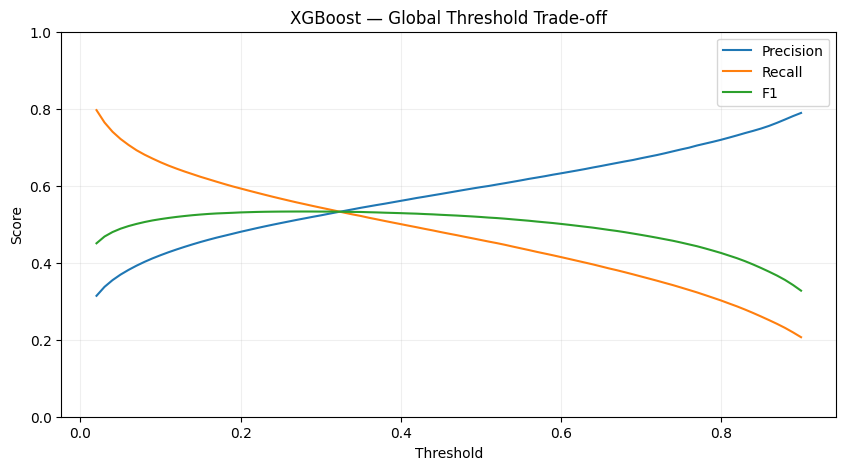

In [6]:
# Plot XGBoost — Global Threshold Trade-off
plt.figure(figsize=(10, 5))
plt.plot(global_sweep["threshold"], global_sweep["precision"], label="Precision")
plt.plot(global_sweep["threshold"], global_sweep["recall"], label="Recall")
plt.plot(global_sweep["threshold"], global_sweep["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost — Global Threshold Trade-off")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.2)
plt.show()
